In [1]:
using QuadGK, LaTeXStrings, Plots, LinearAlgebra, BenchmarkTools,StaticArrays;
using DataFrames, CSV,Interpolations,Suppressor,Polynomials;
import JLD,ForwardDiff;
using Plots.PlotMeasures;
import SymPy;

In [2]:
gr(frame=:box,size=(400, 300));

In [3]:
const unit = 1.0e-3;
const mpic = 139.57018unit; const mpi0 = 134.9766unit;
const meta = 547.862unit; const mkc = 493.677unit; const mk0 = 497.614unit;
const mpi = (2mpic + mpi0)/3; const mk = (mkc + mk0)/2;
const mπ=mpi;
const mJψ=3.0969;
const metap=0.95778;

In [4]:
# redefine sqrt so that its cut is along the positive x axis
function xsqrt(x)
    imag(x) >= 0 ? sqrt(x + 0im) : -sqrt(x - 0im)
end

# redefine angle so that its cut is along the positive x axis
function xangle(x)
    imag(x) >= 0 ? angle(x + 0im) : angle(x) + 2 * π
end

# redefine log so that its cut is along the positive x axis
function xlog(x)
    imag(x) >= 0 ? log(x + 0im) : log(x) + im * 2 * π
end
λ(x, y, z) = x^2 + y^2 + z^2 - 2 * x * y - 2 * x * z - 2 * y * z;

In [5]:
qon(s,m1,m2)=sqrt(s-(m1-m2)^2+0im)*xsqrt(s-(m1+m2)^2)/(2*sqrt(s))

qon (generic function with 1 method)

In [6]:
Chebyshev_arr=Array{Any}(undef,10);

In [7]:
SymPy.@syms x
Chebyshev_arr[1]=1+0.0*x;
Chebyshev_arr[2]=x;
for i in 2:9
    Chebyshev_arr[i+1]=SymPy.simplify(2*x*Chebyshev_arr[i]-Chebyshev_arr[i-1])
end

In [8]:
Chebyshev_arr[1]

1

In [9]:
Chebyshev_lamb_arr=[SymPy.lambdify(Chebyshev_arr[i]) for i in eachindex(Chebyshev_arr)];

In [15]:
Chebyshev_lamb_arr[1](1.0)

1.0

# N/D paramterization

In [10]:
function ρN(s;g=113,sR=1.5,n=7)
    λ0=s<=(mpi+meta)^2 ? 0.0 : λ(s,meta^2,mpi^2)
    return g*λ0^(5/2)/(s+sR)^n
end

ρN (generic function with 1 method)

In [11]:
function Dfunc(s;cv=[1.5129,0.532,0.253,2.38],ϵ=1.0e-8,rtol=1.0e-4)
    c0,c1,c2,c3=cv
    res=zero(ComplexF64)
    res+=c0-c1*s-c2/(c3-s)
    res-=quadgk(x->s/π*ρN(x)/x/(x-s-im*ϵ),(mpi+meta)^2,Inf;rtol=rtol)[1]
end

Dfunc (generic function with 1 method)

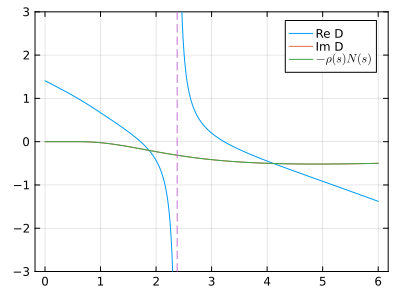

In [12]:
plot(eps():0.002:6.0,[x->real(Dfunc(x)),x->imag(Dfunc(x))]
    ,label=["Re D" "Im D"],ylims=(-3,3))
plot!(eps():0.002:6.0,x->-ρN(x),label=L"-\rho(s)N(s)")
vline!([2.38],ls=:dash,label=false)

In [17]:
function nfunc(s;c3=2.38,av=[0.471,0.134,-1.484,0.879,2.616,-3.652,1.821])
    Λ=1.0
    ω=s/(s+Λ)
    # return 1/(c3-s)*Polynomials.ChebyshevT(av)(ω) # cannot evaluate for complex value
    return 1/(c3-s)*sum([av[i]*Chebyshev_lamb_arr[i](ω) for i in eachindex(av)])
end

nfunc (generic function with 1 method)

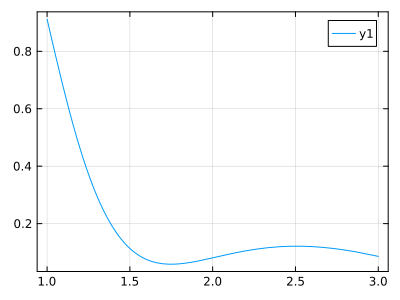

In [37]:
plot(x->abs(nfunc(x^2)*(2.38-x^2)),1.0,3.0)

In [18]:
function amp(s;teff=-0.1)
    q,pπη=sqrt(λ(s,mpi^2,teff))/(2*sqrt(s)),qon(s,mpi,meta)
    return pπη^2*q*nfunc(s)/Dfunc(s)
end

amp (generic function with 1 method)

In [19]:
intensity(s;N=1e6)=N*qon(s,mpi,meta)*abs2(amp(s))

intensity (generic function with 1 method)

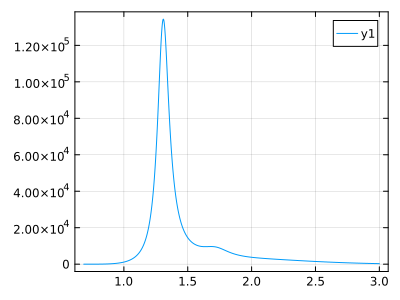

In [20]:
plot((mpi+meta+eps()):0.001:3.0,E->real(intensity(E^2)))

## pole positions

In [21]:
function Dfunc_rs(s;rs=1,g=113,sR=1.5,n=7)
    ρN0=g*λ(s,meta^2,mpi^2)^2/(s+sR)^n*sqrt(s-(meta-mpi)^2+0im)*xsqrt(s-(meta+mpi)^2+0im)
    Dfunc(s)+Int(rs==2)*2*im*ρN0
end

Dfunc_rs (generic function with 1 method)

In [22]:
Dfunc_rs((1.307-im*0.112/2)^2;rs=2)

-0.0029260742045522092 + 0.00035524984612306243im

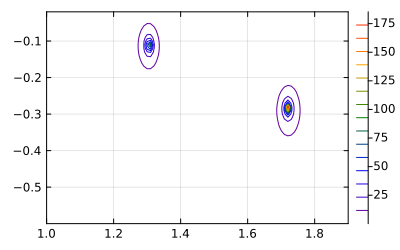

In [23]:
let ReEv=collect(1.0:0.01:1.9),ImEv=collect(-0.6:0.01:-0.02)
    resmat=[1/Dfunc_rs((x+im*y/2)^2;rs=2) for y in ImEv,x in ReEv]
    contour(ReEv,ImEv,abs.(resmat),size=(400,250),color=:rainbow) #,fill=true
end

In [24]:
using NLsolve;

In [25]:
function Dfunc_pole!(F, x)
    m, Γ = x
    tmp = Dfunc_rs((m-im*Γ/2)^2;rs=2)
    F[1] = real(tmp)
    F[2] = imag(tmp)
end

Dfunc_pole! (generic function with 1 method)

In [26]:
NLsolve.nlsolve((F, x) -> Dfunc_pole!(F, x), [1.307, 0.112])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [1.307, 0.112]
 * Zero: [1.3059442688190943, 0.11172043880431418]
 * Inf-norm of residuals: 0.000000
 * Iterations: 2
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 3
 * Jacobian Calls (df/dx): 3

In [27]:
NLsolve.nlsolve((F, x) -> Dfunc_pole!(F, x), [1.720, 0.280])

Results of Nonlinear Solver Algorithm
 * Algorithm: Trust-region with dogleg and autoscaling
 * Starting Point: [1.72, 0.28]
 * Zero: [1.719922228017251, 0.2842665957563485]
 * Inf-norm of residuals: 0.000000
 * Iterations: 2
 * Convergence: true
   * |x - x'| < 0.0e+00: false
   * |f(x)| < 1.0e-08: true
 * Function Calls (f): 3
 * Jacobian Calls (df/dx): 3

In [28]:
function ahat_ac(s)
    imag(s)>=0.0 ? nfunc(s)/Dfunc_rs(s;rs=1) : nfunc(s)/Dfunc_rs(s;rs=2)
end

ahat_ac (generic function with 1 method)

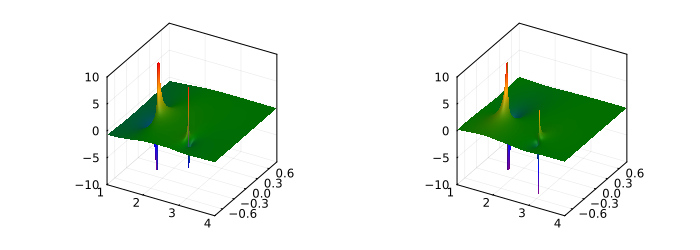

In [33]:
let Resv=collect(1:0.002:4.0),Imsv=collect(-0.8:0.002:0.8)
    resmat=[ahat_ac(x+im*y) for y in Imsv,x in Resv]
    plt1=surface(Resv,Imsv,real.(resmat),legend=false,color=:rainbow,zlims=(-10,10))
    plt2=surface(Resv,Imsv,imag.(resmat),legend=false,color=:rainbow,zlims=(-10,10))
    plot(plt1,plt2,layout=(1,2),size=(700,250))
end